# BharatEO-v0 with real ESA WorldCover pixels

This notebook is the smallest honest version of the BharatEO-v0 idea: use real Earth observation labels, split them into ViT-style tokens, mask most tokens, and train a tiny model with two objectives.

The data here is **actual ESA WorldCover 10 m 2021 v200**, read from the public Cloud Optimized GeoTIFFs that cover north India. There are no generated land-cover maps and no synthetic spectral signatures.

What this notebook demonstrates:

- how a `128 x 128` Earth observation chip becomes `64` patch tokens,
- how ESA WorldCover classes collapse into the BharatEO 8-class label space,
- how masked **RGB regression** reconstruction works on a real EO chip,
- how the auxiliary ESA patch classification objective works,
- how many tokens the run consumes,
- how the same scaffold extends to Sentinel-2 RGB/10-band pretraining.

What changed in this v0.2 pass:

- **Input is now 3-channel RGB** rendered from the WorldCover class palette, instead of an 8-channel one-hot. This makes the reconstruction objective an L1 regression on real-valued pixels — the same shape of objective used in a Sentinel-2 MAE.
- **More data**: chips are sampled from three different `2048 x 2048` ROIs inside the N27E075 tile (Delhi NCR, Shekhawati in Rajasthan, the Mathura/UP cropland belt) instead of a single Delhi crop.
- **More pretraining**: a slightly bigger encoder runs for many more epochs over many more chips.

Important limitation: the input chip is still a colorized rendering of WorldCover classes, not Sentinel-2 reflectance. In the full BharatEO-v0 run, the input becomes `10 x 128 x 128` Sentinel-2 L2A reflectance; the only change to the pipeline is the source of the pixels. WorldCover stays as the weak patch-label supervision.

## Data source

The notebook reads a small crop from this official WorldCover tile:

`https://esa-worldcover.s3.eu-central-1.amazonaws.com/v200/2021/map/ESA_WorldCover_10m_2021_v200_N27E075_Map.tif`

That COG covers `75E-78E, 27N-30N`, including Delhi/NCR. The full tile is about 87 MB, but `rasterio` reads only the requested window. A local cache stores only the derived `2048 x 2048` ROI so repeated runs do not hit the network.

Attribution: ESA WorldCover project / Contains modified Copernicus Sentinel data (2021) processed by ESA WorldCover consortium.

Citation: Zanaga et al. 2022, ESA WorldCover 10 m 2021 v200, https://doi.org/10.5281/zenodo.7254221.

In [29]:
from pathlib import Path
import os
import random
import warnings

os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/matplotlib-cache")
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

%matplotlib inline
%config InlineBackend.figure_format = "retina"

import numpy as np
import matplotlib.pyplot as plt

import rasterio
from rasterio.windows import Window

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 240,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
warnings.filterwarnings("ignore", message="enable_nested_tensor.*")

device = torch.device("cpu")
print("device:", device)


device: cpu


## Chip geometry and token accounting

BharatEO-v0 uses `128 x 128` chips and `16 x 16` patches. That means every image has:

- `8 x 8 = 64` spatial tokens,
- `16 x 16 = 256` pixels per token,
- 75% masked tokens during pretraining.

For this RGB demo, each pixel is a 3-channel RGB color rendered from the WorldCover class palette. A token therefore has `3 x 16 x 16 = 768` raw values. In the real Sentinel-2 V0 the token has `10 x 16 x 16 = 2,560` reflectance values, but the rest of the pipeline is identical.

In [30]:
IMG_SIZE = 128
PATCH_SIZE = 16
GRID_SIZE = IMG_SIZE // PATCH_SIZE
NUM_PATCHES = GRID_SIZE * GRID_SIZE
MASK_RATIO = 0.75
DATASET_SIZE = 384
BATCH_SIZE = 16
EPOCHS = 20
PATCH_LOSS_WEIGHT = 0.2
NUM_INPUT_CHANNELS = 3  # RGB rendering of WorldCover

CLASS_NAMES = [
    "tree",
    "cropland",
    "grass_shrub",
    "built_up",
    "bare_sparse",
    "water",
    "wetland_mangrove",
    "rare_other",
]
NUM_CLASSES = len(CLASS_NAMES)
TOKEN_DIM = NUM_INPUT_CHANNELS * PATCH_SIZE * PATCH_SIZE

demo_total_tokens = DATASET_SIZE * NUM_PATCHES * EPOCHS
demo_masked_tokens = int(demo_total_tokens * MASK_RATIO)
demo_visible_tokens = demo_total_tokens - demo_masked_tokens
demo_masked_pixel_targets = demo_masked_tokens * PATCH_SIZE * PATCH_SIZE

print(f"RGB input tensor:        {NUM_INPUT_CHANNELS} x {IMG_SIZE} x {IMG_SIZE}")
print(f"patch grid:              {GRID_SIZE} x {GRID_SIZE} = {NUM_PATCHES} tokens/image")
print(f"token dimension:         {TOKEN_DIM:,} RGB values/token")
print(f"demo images:             {DATASET_SIZE}")
print(f"demo epochs:             {EPOCHS}")
print(f"total token presentations: {demo_total_tokens:,}")
print(f"visible token inputs:      {demo_visible_tokens:,}")
print(f"masked token targets:      {demo_masked_tokens:,}")
print(f"masked pixel regression targets: {demo_masked_pixel_targets:,}")

RGB input tensor:        3 x 128 x 128
patch grid:              8 x 8 = 64 tokens/image
token dimension:         768 RGB values/token
demo images:             384
demo epochs:             20
total token presentations: 491,520
visible token inputs:      122,880
masked token targets:      368,640
masked pixel regression targets: 94,371,840


## ESA WorldCover labels

WorldCover v200 has 11 native class codes. For BharatEO-v0 we collapse them into 8 patch-label classes. This keeps the weak supervision compact while preserving the categories that matter for many India environmental tasks.

In [31]:
NATIVE_WORLDCOVER_CLASSES = {
    10: "Tree cover",
    20: "Shrubland",
    30: "Grassland",
    40: "Cropland",
    50: "Built-up",
    60: "Bare / sparse vegetation",
    70: "Snow and ice",
    80: "Permanent water bodies",
    90: "Herbaceous wetland",
    95: "Mangroves",
    100: "Moss and lichen",
}

NATIVE_TO_COLLAPSED_NAME = {
    10: "tree",
    20: "grass_shrub",
    30: "grass_shrub",
    40: "cropland",
    50: "built_up",
    60: "bare_sparse",
    70: "rare_other",
    80: "water",
    90: "wetland_mangrove",
    95: "wetland_mangrove",
    100: "rare_other",
}

CLASS_TO_ID = {name: i for i, name in enumerate(CLASS_NAMES)}
NATIVE_TO_COLLAPSED_ID = np.full(256, CLASS_TO_ID["rare_other"], dtype=np.int64)
for native_code, collapsed_name in NATIVE_TO_COLLAPSED_NAME.items():
    NATIVE_TO_COLLAPSED_ID[native_code] = CLASS_TO_ID[collapsed_name]

CLASS_COLORS = np.array([
    [35, 132, 67],     # tree
    [188, 189, 34],    # cropland
    [127, 191, 123],   # grass/shrub
    [215, 48, 39],     # built-up
    [217, 164, 65],    # bare/sparse
    [49, 130, 189],    # water
    [44, 162, 95],     # wetland/mangrove
    [189, 189, 189],   # rare/other
], dtype=np.float32) / 255.0

for native_code, native_name in NATIVE_WORLDCOVER_CLASSES.items():
    collapsed = NATIVE_TO_COLLAPSED_NAME[native_code]
    print(f"{native_code:3d} {native_name:28s} -> {collapsed}")


 10 Tree cover                   -> tree
 20 Shrubland                    -> grass_shrub
 30 Grassland                    -> grass_shrub
 40 Cropland                     -> cropland
 50 Built-up                     -> built_up
 60 Bare / sparse vegetation     -> bare_sparse
 70 Snow and ice                 -> rare_other
 80 Permanent water bodies       -> water
 90 Herbaceous wetland           -> wetland_mangrove
 95 Mangroves                    -> wetland_mangrove
100 Moss and lichen              -> rare_other


## Load three real WorldCover crops from the N27E075 tile

The N27E075 v200 tile covers `75-78 E, 27-30 N`, so it spans Delhi NCR plus large parts of Haryana, Rajasthan, and western UP. We sample three `2048 x 2048` ROIs (each ~20 km wide) from inside this tile so the chip distribution is not just one city:

- **Delhi NCR** (`77.23 E, 28.61 N`) — built-up dominant.
- **Shekhawati** (`75.80 E, 28.50 N`) — semi-arid Rajasthan with bare soil and grass/shrub.
- **Mathura belt** (`77.50 E, 27.30 N`) — UP cropland.

Each ROI is read with a `rasterio` window, so only the requested bytes are pulled from S3, and each derived ROI is cached locally.

In [32]:
WORLDCOVER_TILE_URL = "https://esa-worldcover.s3.eu-central-1.amazonaws.com/v200/2021/map/ESA_WorldCover_10m_2021_v200_N27E075_Map.tif"
ROI_SIZE = 2048
ROI_CENTERS = [
    ("delhi_ncr", (77.23, 28.61)),
    ("shekhawati", (75.80, 28.50)),
    ("mathura_belt", (77.50, 27.30)),
]
CACHE_DIR = Path("data")


def load_one_roi(name, lon_lat, cache_dir=CACHE_DIR, roi_size=ROI_SIZE):
    cache_path = cache_dir / f"worldcover_2021_v200_N27E075_{name}_roi_{roi_size}.npz"
    if cache_path.exists():
        cached = np.load(cache_path, allow_pickle=True)
        return cached["roi"], {
            "name": name,
            "url": str(cached["url"]),
            "crs": str(cached["crs"]),
            "bounds": tuple(cached["bounds"].tolist()),
            "center_lon_lat": tuple(cached["center_lon_lat"].tolist()),
            "source": "local cache derived from ESA WorldCover COG",
        }

    cache_dir.mkdir(parents=True, exist_ok=True)
    with rasterio.open(WORLDCOVER_TILE_URL) as src:
        center_row, center_col = src.index(*lon_lat)
        window = Window(center_col - roi_size // 2, center_row - roi_size // 2, roi_size, roi_size)
        roi = src.read(1, window=window)
        bounds = src.window_bounds(window)
        meta = {
            "name": name,
            "url": WORLDCOVER_TILE_URL,
            "crs": str(src.crs),
            "bounds": tuple(bounds),
            "center_lon_lat": lon_lat,
            "source": "ESA WorldCover 10 m 2021 v200 COG",
        }

    np.savez_compressed(
        cache_path,
        roi=roi,
        url=np.array(WORLDCOVER_TILE_URL),
        crs=np.array(meta["crs"]),
        bounds=np.array(meta["bounds"], dtype=np.float64),
        center_lon_lat=np.array(lon_lat, dtype=np.float64),
    )
    return roi, meta


roi_arrays = []
roi_metas = []
for name, lon_lat in ROI_CENTERS:
    roi, meta = load_one_roi(name, lon_lat)
    roi_arrays.append(roi)
    roi_metas.append(meta)

for meta, roi in zip(roi_metas, roi_arrays):
    unique_codes, counts = np.unique(roi, return_counts=True)
    print(f"\n[{meta['name']}] center {meta['center_lon_lat']} bounds {meta['bounds']}")
    print(f"  shape {roi.shape} dtype {roi.dtype}")
    print(f"  native codes: {dict(zip(unique_codes.tolist(), counts.tolist()))}")


[delhi_ncr] center (77.23, 28.61) bounds (77.14466666666667, 28.52466666666667, 77.31533333333333, 28.695333333333334)
  shape (2048, 2048) dtype uint8
  native codes: {10: 1427563, 20: 30300, 30: 97974, 40: 206512, 50: 2307399, 60: 30563, 80: 91525, 90: 2468}

[shekhawati] center (75.8, 28.5) bounds (75.71458333333334, 28.414666666666665, 75.88525, 28.585333333333335)
  shape (2048, 2048) dtype uint8
  native codes: {10: 126256, 20: 207313, 30: 26380, 40: 3701224, 50: 128551, 60: 3862, 80: 718}

[mathura_belt] center (77.5, 27.3) bounds (77.41466666666666, 27.21475, 77.58533333333334, 27.385416666666668)
  shape (2048, 2048) dtype uint8
  native codes: {10: 114752, 20: 445, 30: 117319, 40: 3647314, 50: 303675, 60: 6091, 80: 4695, 90: 13}


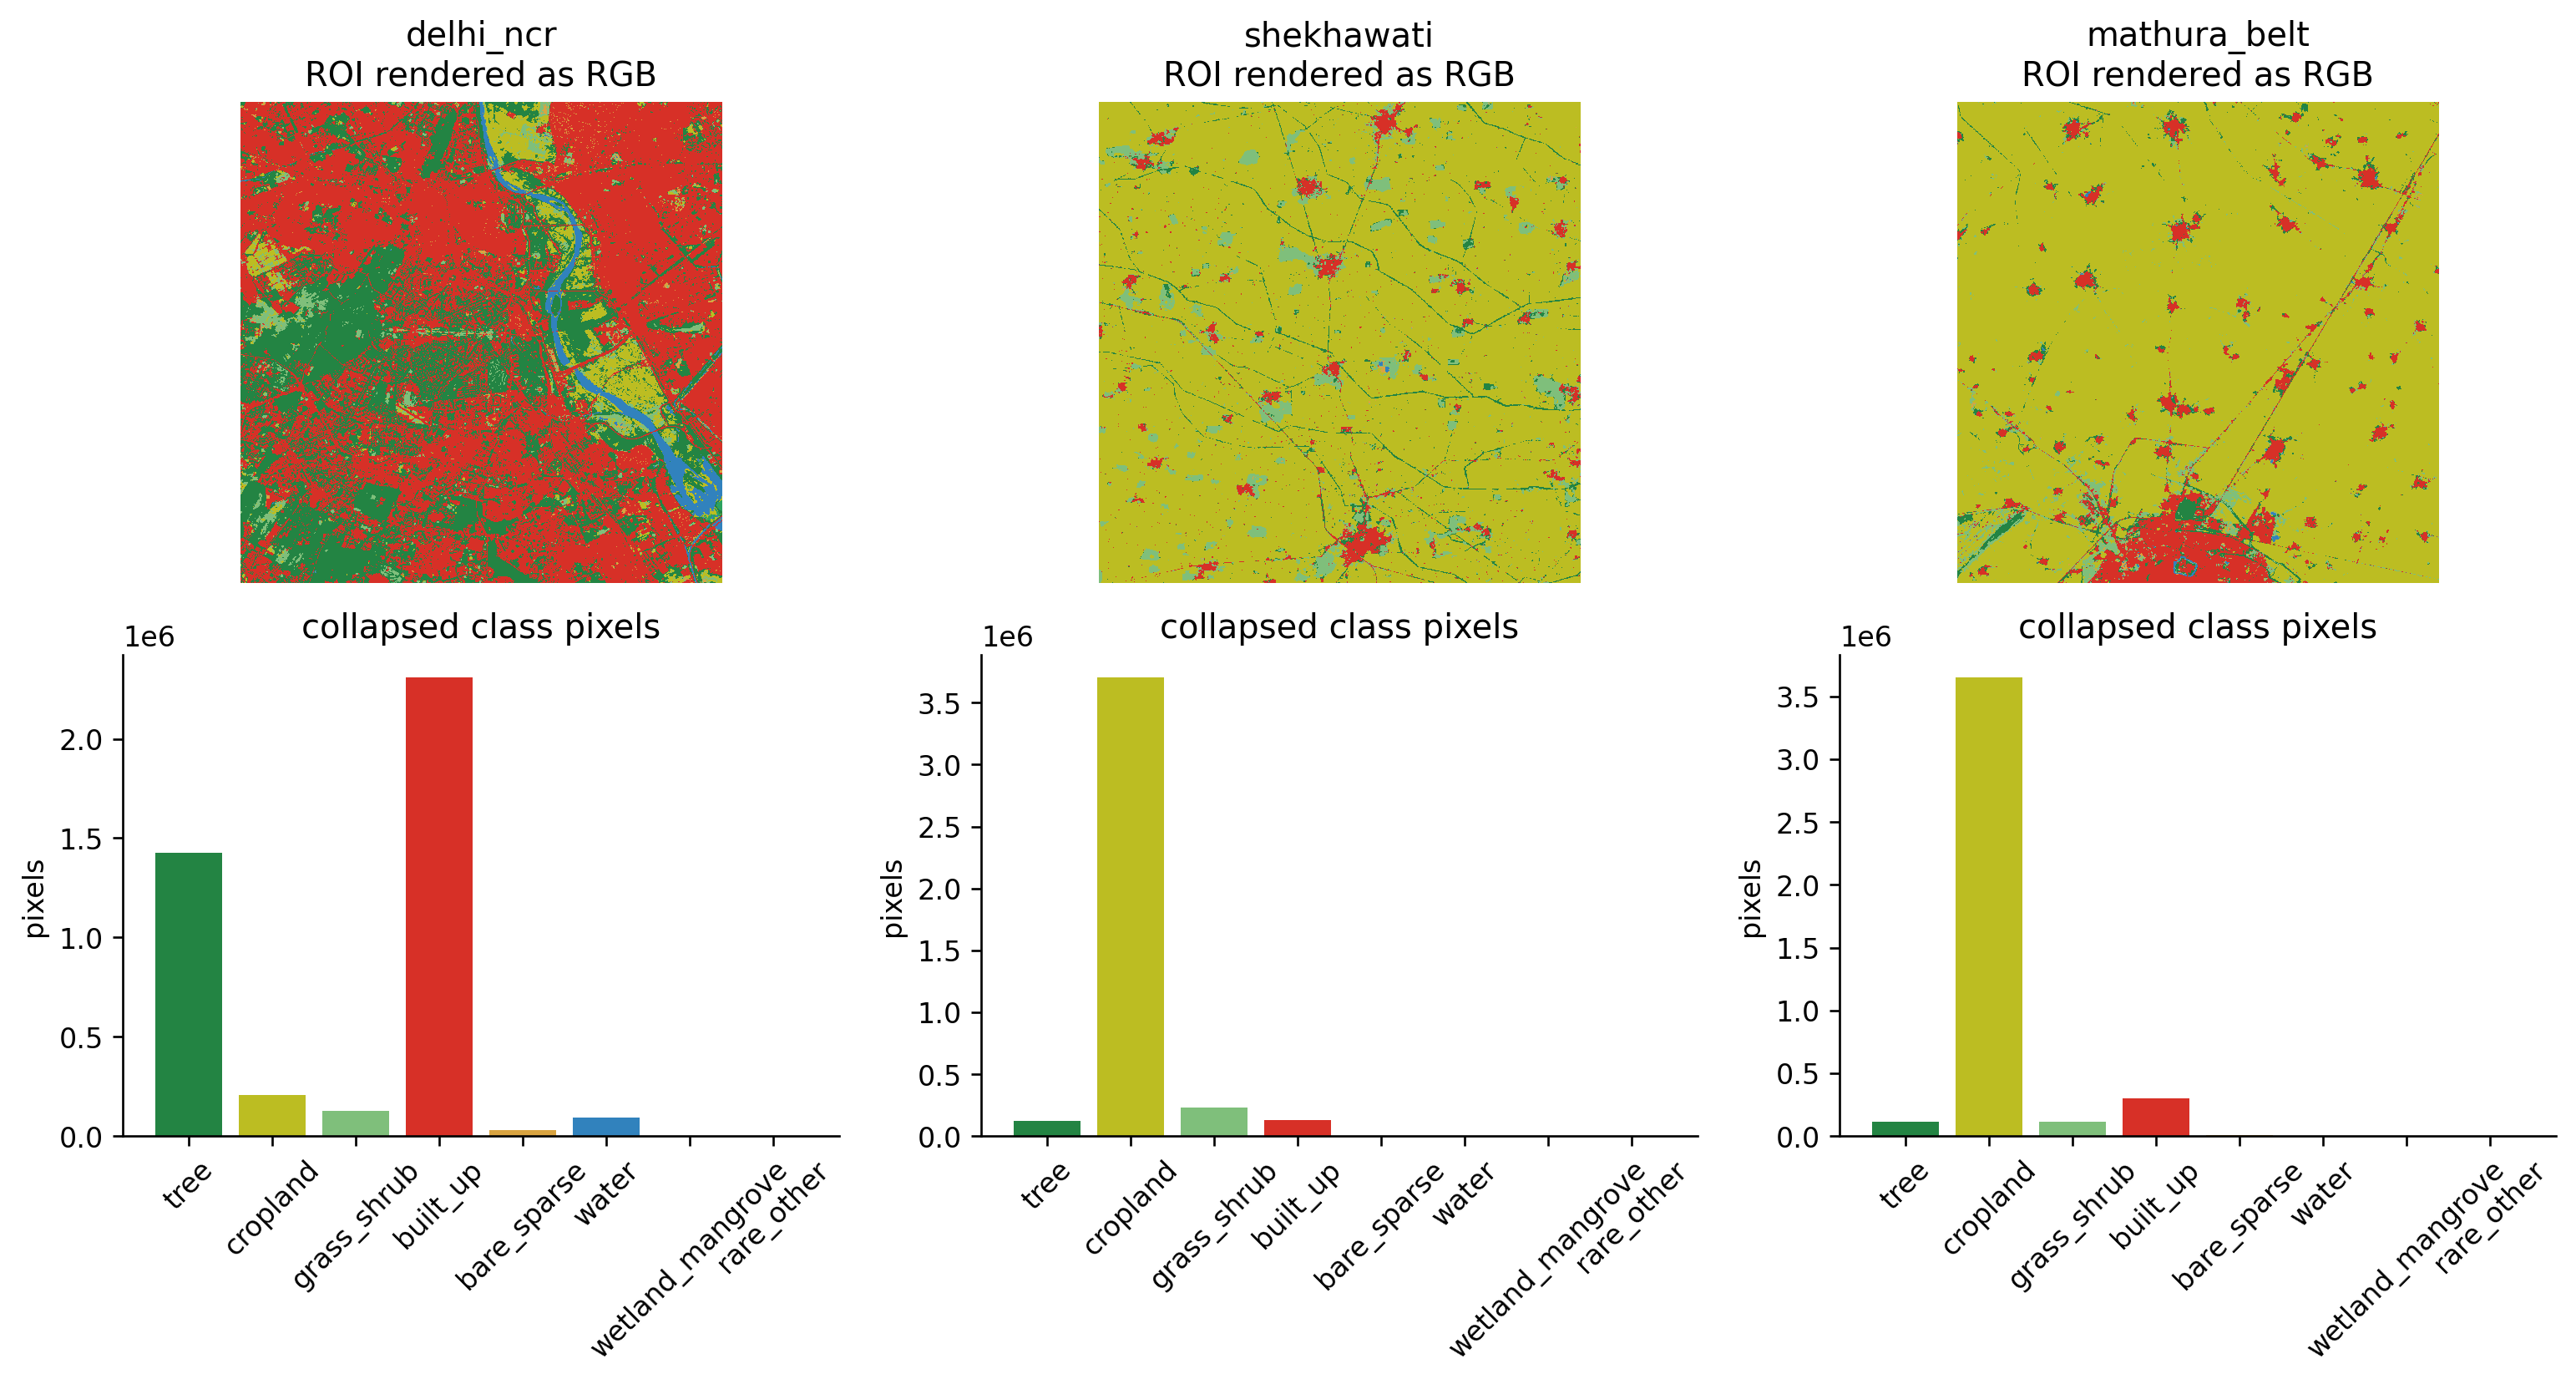

In [33]:
def collapse_worldcover(native_map):
    return NATIVE_TO_COLLAPSED_ID[native_map]


def labels_to_rgb(labels):
    arr = labels.detach().cpu().numpy() if torch.is_tensor(labels) else labels
    return CLASS_COLORS[arr]


def labels_to_rgb_input(labels):
    """H x W int label map -> 3 x H x W float RGB tensor in [0, 1]."""
    return CLASS_COLORS[labels].transpose(2, 0, 1).astype(np.float32)


def patch_mode_labels(label_map):
    blocks = label_map.reshape(GRID_SIZE, PATCH_SIZE, GRID_SIZE, PATCH_SIZE)
    blocks = blocks.transpose(0, 2, 1, 3).reshape(GRID_SIZE, GRID_SIZE, -1)
    out = np.zeros((GRID_SIZE, GRID_SIZE), dtype=np.int64)
    for r in range(GRID_SIZE):
        for c in range(GRID_SIZE):
            out[r, c] = np.bincount(blocks[r, c], minlength=NUM_CLASSES).argmax()
    return out


collapsed_rois = [collapse_worldcover(roi) for roi in roi_arrays]

fig, axes = plt.subplots(2, len(collapsed_rois), figsize=(13, 7))
for col, (meta, collapsed) in enumerate(zip(roi_metas, collapsed_rois)):
    pixel_counts = np.bincount(collapsed.ravel(), minlength=NUM_CLASSES)
    axes[0, col].imshow(labels_to_rgb(collapsed), interpolation="nearest")
    axes[0, col].set_title(f"{meta['name']}\nROI rendered as RGB")
    axes[0, col].axis("off")
    axes[1, col].bar(CLASS_NAMES, pixel_counts, color=CLASS_COLORS)
    axes[1, col].set_title("collapsed class pixels")
    axes[1, col].tick_params(axis="x", rotation=45)
    axes[1, col].set_ylabel("pixels")
plt.tight_layout()

## Build actual WorldCover chips

Each sample is a real `128 x 128` WorldCover crop, drawn from one of the three ROIs in round robin. The model input is a 3-channel RGB rendering. We also keep two label tensors used for diagnostics and for the auxiliary objective:

- pixel labels: one collapsed ESA class per 10 m pixel,
- patch labels: the dominant collapsed ESA class inside each `16 x 16` token.

In [34]:
class WorldCoverChipDataset(Dataset):
    """Sample 128x128 WorldCover chips, render to RGB, attach labels.

    Chips are drawn from a list of ROIs in round-robin so the dataset is balanced
    across regions (urban / arid / cropland) rather than dominated by one ROI.
    """

    def __init__(self, roi_natives, n=DATASET_SIZE, chip_size=IMG_SIZE, seed=SEED, min_classes=2):
        self.samples = []
        rng = np.random.default_rng(seed)
        attempts = 0
        target_per_roi = [n // len(roi_natives)] * len(roi_natives)
        for i in range(n - sum(target_per_roi)):
            target_per_roi[i] += 1

        for roi_idx, (roi_native, want) in enumerate(zip(roi_natives, target_per_roi)):
            height, width = roi_native.shape
            collected = 0
            while collected < want and attempts < n * 400:
                attempts += 1
                row = int(rng.integers(0, height - chip_size))
                col = int(rng.integers(0, width - chip_size))
                collapsed = collapse_worldcover(roi_native[row:row + chip_size, col:col + chip_size])
                if np.unique(collapsed).size < min_classes:
                    continue
                self.samples.append((
                    labels_to_rgb_input(collapsed),
                    collapsed.astype(np.int64),
                    patch_mode_labels(collapsed),
                    roi_idx,
                ))
                collected += 1

        if len(self.samples) != n:
            raise RuntimeError(f"Built {len(self.samples)} chips, expected {n}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        x, labels, patch_labels, _roi_idx = self.samples[idx]
        return torch.from_numpy(x), torch.from_numpy(labels), torch.from_numpy(patch_labels)


dataset = WorldCoverChipDataset(roi_arrays)
x0, labels0, patch_labels0 = dataset[0]
roi_index_counts = np.bincount([s[3] for s in dataset.samples], minlength=len(roi_arrays))
print("dataset chips:", len(dataset))
print("chips per ROI:", dict(zip([m["name"] for m in roi_metas], roi_index_counts.tolist())))
print("RGB input:", tuple(x0.shape), x0.dtype, f"min {x0.min().item():.3f} max {x0.max().item():.3f}")
print("pixel labels:", tuple(labels0.shape), sorted(torch.unique(labels0).tolist()))
print("patch labels:", tuple(patch_labels0.shape), sorted(torch.unique(patch_labels0).tolist()))

dataset chips: 384
chips per ROI: {'delhi_ncr': 128, 'shekhawati': 128, 'mathura_belt': 128}
RGB input: (3, 128, 128) torch.float32 min 0.133 max 0.851
pixel labels: (128, 128) [0, 1, 2, 3, 4, 5]
patch labels: (8, 8) [0, 2, 3, 4]


## More examples

The top row shows the actual RGB chip the model sees. The bottom row shows the `8 x 8` patch labels that the auxiliary ESA classification head learns to predict from the same chip.

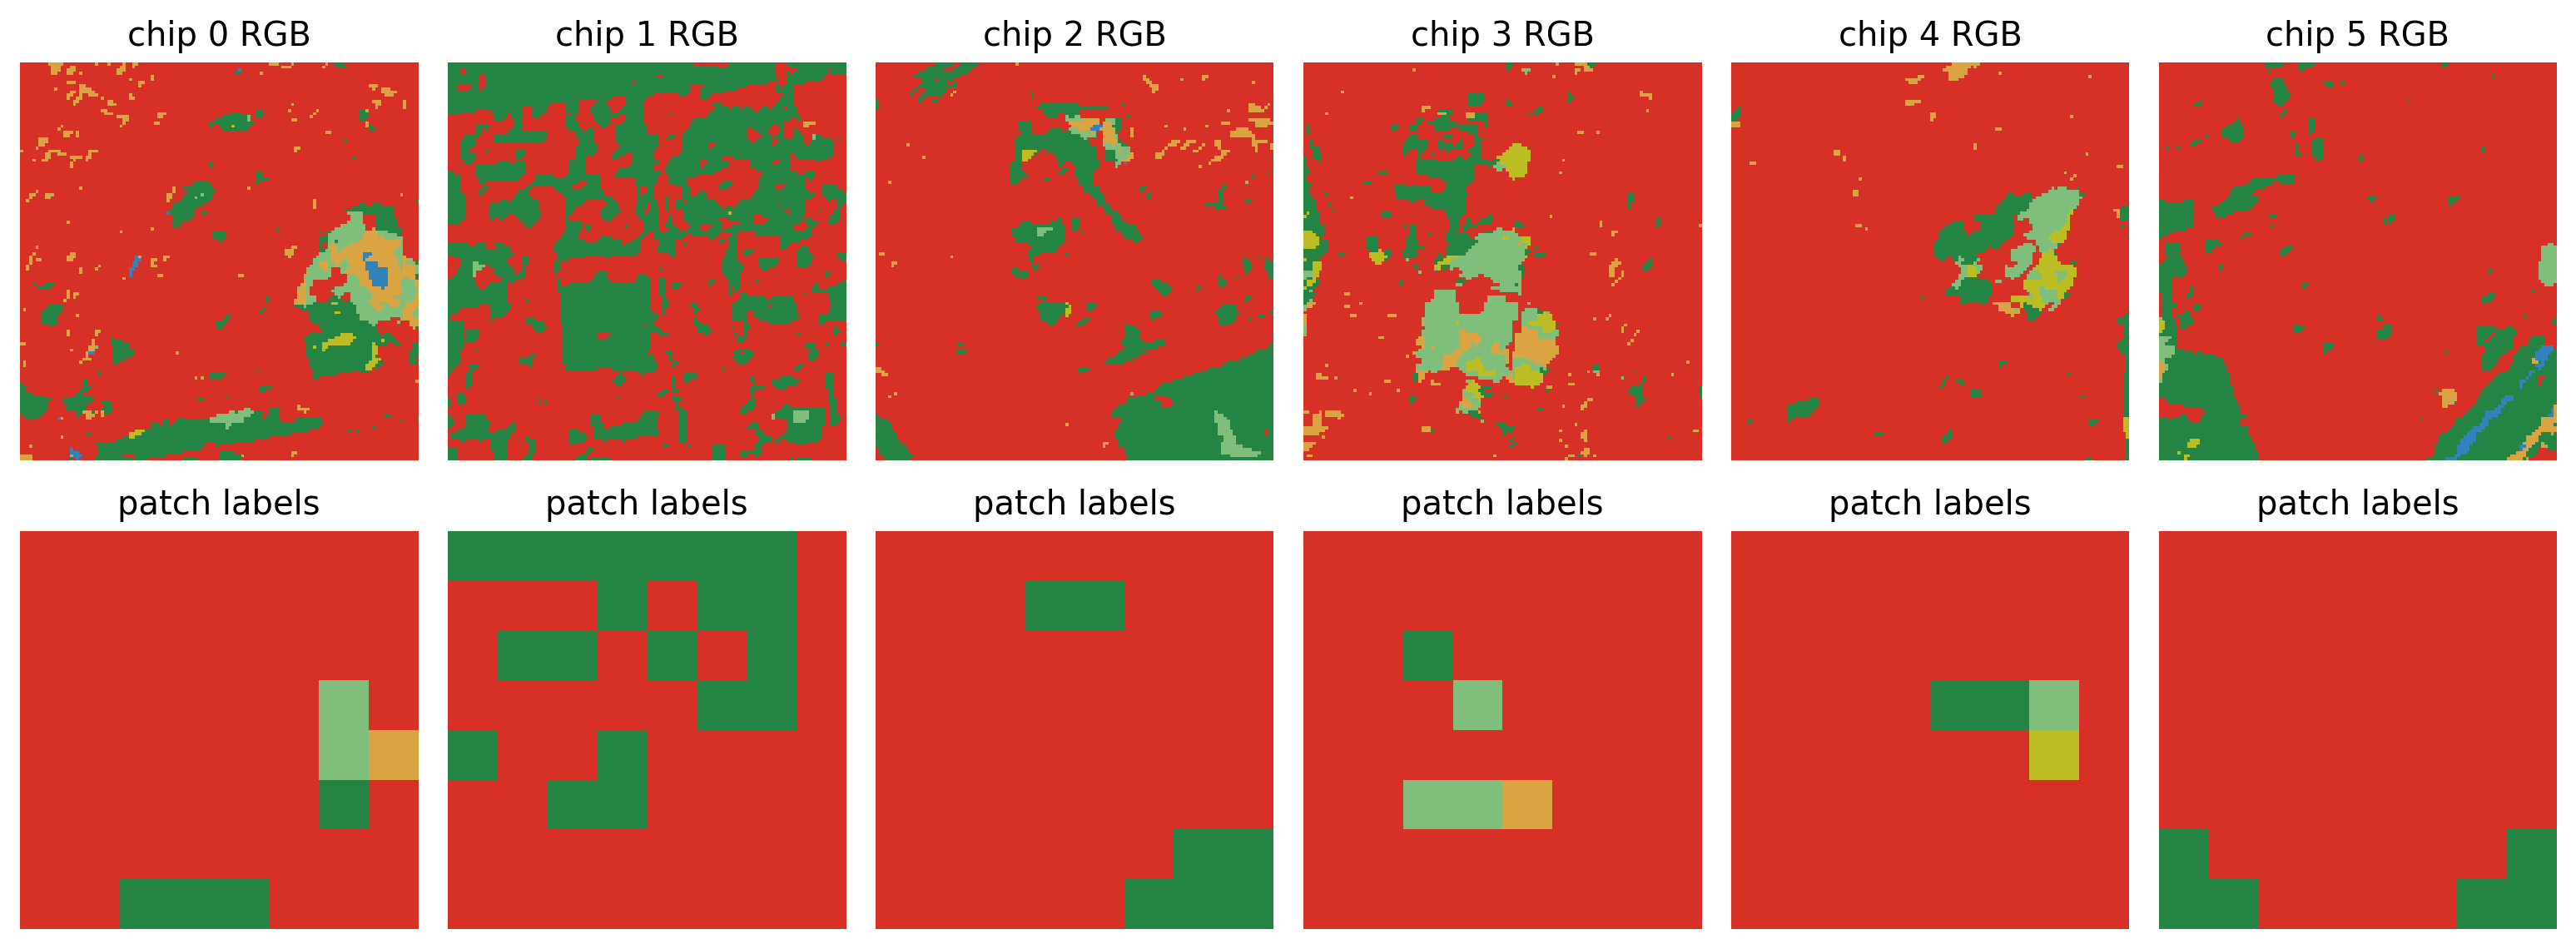

In [35]:
def rgb_chip_to_image(x):
    """3 x H x W tensor -> H x W x 3 numpy in [0, 1] for imshow."""
    return x.detach().cpu().numpy().transpose(1, 2, 0)


example_indices = [0, 1, 2, 3, 4, 5]
fig, axes = plt.subplots(2, len(example_indices), figsize=(13, 5))
for col, idx in enumerate(example_indices):
    x, _labels, patch_labels = dataset[idx]
    axes[0, col].imshow(rgb_chip_to_image(x), interpolation="nearest")
    axes[0, col].set_title(f"chip {idx} RGB")
    axes[1, col].imshow(labels_to_rgb(patch_labels), interpolation="nearest")
    axes[1, col].set_title("patch labels")
    axes[0, col].axis("off")
    axes[1, col].axis("off")
plt.tight_layout()

## Patch tokens

Patchification converts the image tensor into a sequence. For one RGB chip:

`3 x 128 x 128 -> 64 x 768`

The transformer sees the sequence length `64`; the `768` raw RGB values per token are projected to the model width by a learned linear patch embedding.

In [36]:
def patchify(x, patch_size=PATCH_SIZE):
    """B x C x H x W -> B x N x (C*p*p)."""
    b, c, h, w = x.shape
    p = patch_size
    gh, gw = h // p, w // p
    return x.reshape(b, c, gh, p, gw, p).permute(0, 2, 4, 1, 3, 5).reshape(b, gh * gw, c * p * p)


def patchify_rgb(x, patch_size=PATCH_SIZE):
    """B x C x H x W -> B x N x C x p x p (kept structured for visualization)."""
    b, c, h, w = x.shape
    p = patch_size
    gh, gw = h // p, w // p
    return x.reshape(b, c, gh, p, gw, p).permute(0, 2, 4, 1, 3, 5).reshape(b, gh * gw, c, p, p)


def patchify_label_map(labels, patch_size=PATCH_SIZE):
    """B x H x W -> B x N x p x p."""
    b, h, w = labels.shape
    p = patch_size
    gh, gw = h // p, w // p
    return labels.reshape(b, gh, p, gw, p).permute(0, 1, 3, 2, 4).reshape(b, gh * gw, p, p)


tokens = patchify(x0.unsqueeze(0))
tokens_rgb = patchify_rgb(x0.unsqueeze(0))[0]  # N x 3 x p x p
token_mean_rgb = tokens_rgb.mean(dim=(-1, -2))  # N x 3, mean color of each token
token_brightness = token_mean_rgb.mean(dim=1).reshape(GRID_SIZE, GRID_SIZE)
token_color_var = tokens_rgb.var(dim=(-1, -2)).mean(dim=1).reshape(GRID_SIZE, GRID_SIZE)

print("token tensor:", tuple(tokens.shape))
print("first token mean RGB:", [f"{v:.3f}" for v in token_mean_rgb[0].tolist()])
print("first token internal color variance:", float(tokens_rgb[0].var().item()))

token tensor: (1, 64, 768)
first token mean RGB: ['0.844', '0.222', '0.161']
first token internal color variance: 0.10034258663654327


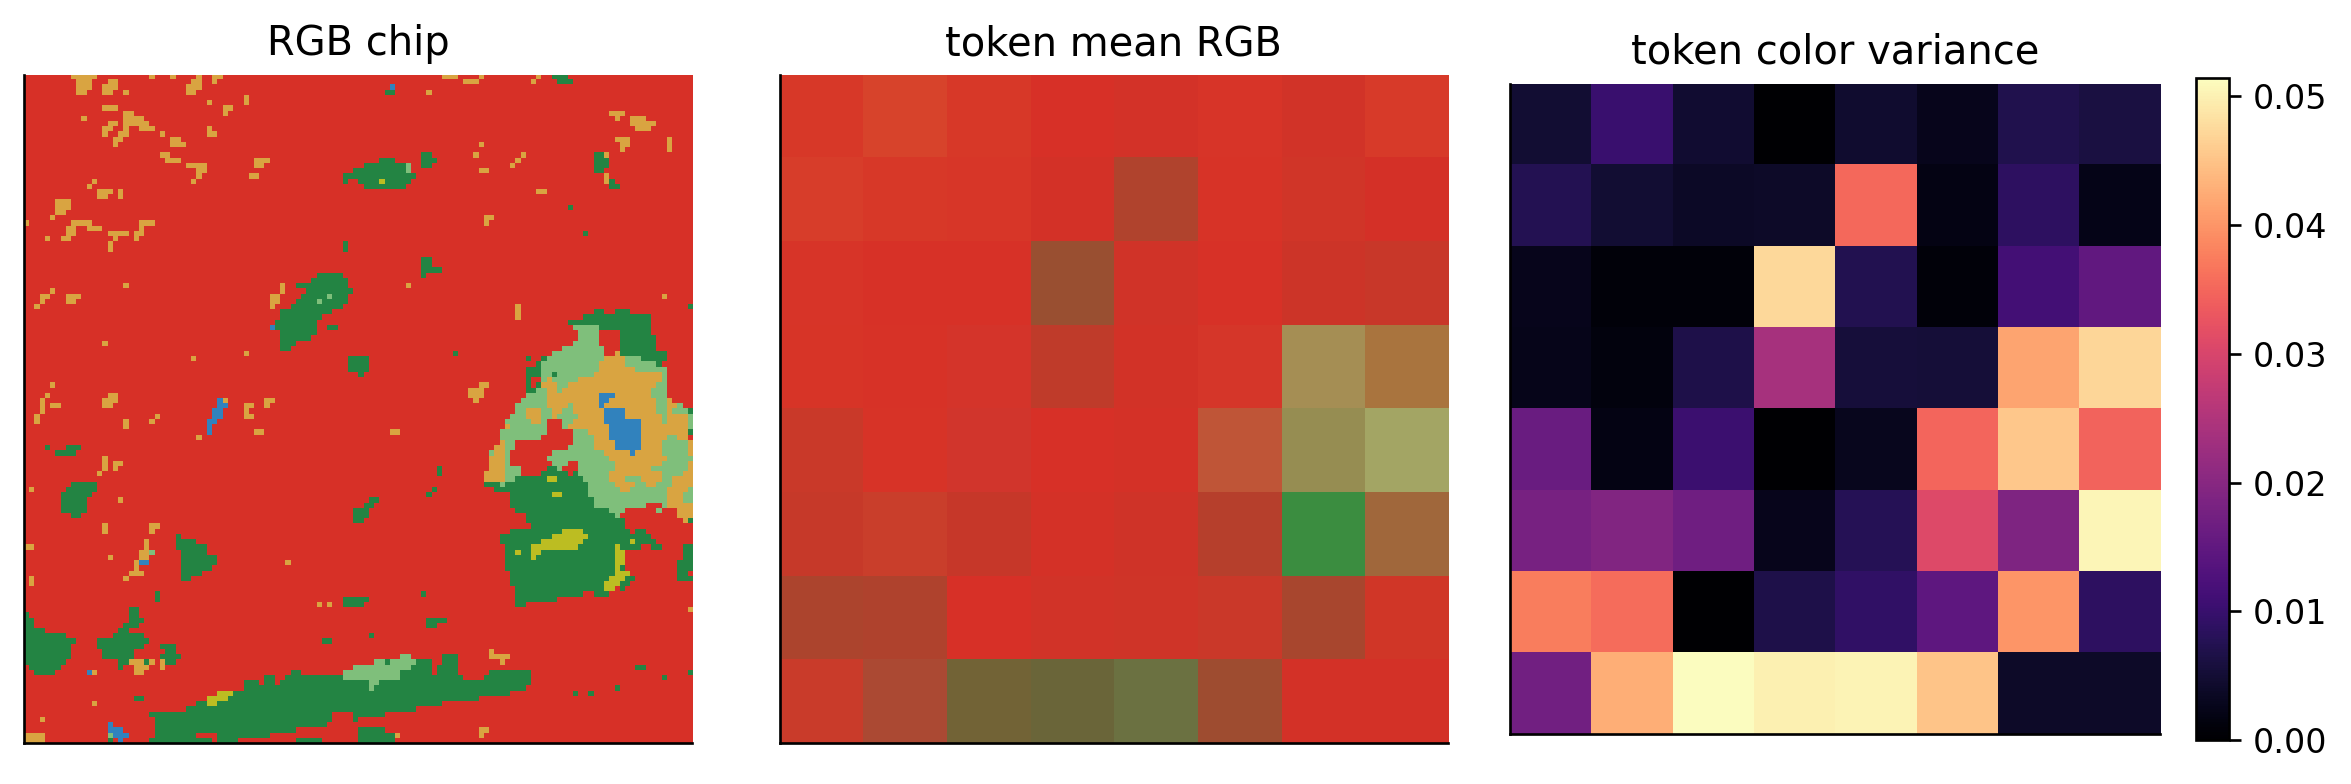

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(10, 3.2))
axes[0].imshow(rgb_chip_to_image(x0), interpolation="nearest")
axes[0].set_title("RGB chip")
mean_rgb_grid = token_mean_rgb.reshape(GRID_SIZE, GRID_SIZE, 3).numpy().clip(0, 1)
axes[1].imshow(mean_rgb_grid, interpolation="nearest")
axes[1].set_title("token mean RGB")
im = axes[2].imshow(token_color_var.numpy(), cmap="magma")
axes[2].set_title("token color variance")
plt.colorbar(im, ax=axes[2], fraction=0.046)
for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()

## Training objectives

This tiny model has two objectives.

**1. Masked RGB regression**

For each image, we mask 75% of patch tokens. The decoder predicts a 3-channel RGB value for every pixel in every token, and the reconstruction loss is computed only on masked tokens with a smooth L1 / Huber loss:

$$
L_{rec} = \frac{1}{3|M|p^2}\sum_{(b,n) \in M}\sum_{c, u, v} \mathrm{SmoothL1}(\hat x_{b,n,c,u,v},\; x_{b,n,c,u,v})
$$

where `p = 16` and `M` is the set of masked patches. This is the same objective used by Sentinel-2 MAEs (the only change there is that `x` is normalized reflectance instead of palette RGB).

**2. ESA patch classification**

Every token also predicts the dominant ESA class in its `16 x 16` patch:

$$
L_{ESA} = \frac{1}{BN}\sum_{b,n}\mathrm{CE}(\hat c_{b,n},\; c_{b,n})
$$

The total loss is:

$$
L = L_{rec} + 0.2 L_{ESA}
$$

In full BharatEO-v0, `L_rec` stays a smooth-L1 loss on normalized Sentinel-2 reflectance; `L_ESA` stays this weak land-cover patch objective.

In [38]:
def random_patch_mask(batch_size, generator=None):
    num_mask = int(NUM_PATCHES * MASK_RATIO)
    noise = torch.rand(batch_size, NUM_PATCHES, generator=generator, device=device)
    ids = noise.argsort(dim=1)
    mask = torch.zeros(batch_size, NUM_PATCHES, dtype=torch.bool, device=device)
    mask.scatter_(1, ids[:, :num_mask], True)
    return mask


class TinyRGBMAE(nn.Module):
    """Small MAE-style encoder that reconstructs masked RGB tokens and predicts
    a per-token ESA WorldCover patch class."""

    def __init__(self, embed_dim=128, depth=3, heads=4):
        super().__init__()
        self.patch_embed = nn.Linear(TOKEN_DIM, embed_dim)
        self.mask_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, NUM_PATCHES, embed_dim))
        layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=heads,
            dim_feedforward=4 * embed_dim,
            dropout=0.0,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(layer, num_layers=depth)
        self.pixel_head = nn.Sequential(nn.LayerNorm(embed_dim), nn.Linear(embed_dim, TOKEN_DIM))
        self.patch_head = nn.Sequential(nn.LayerNorm(embed_dim), nn.Linear(embed_dim, NUM_CLASSES))
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.mask_token, std=0.02)

    def forward(self, x, mask):
        z = self.patch_embed(patchify(x))
        z = torch.where(mask.unsqueeze(-1), self.mask_token.expand_as(z), z)
        z = self.encoder(z + self.pos_embed)
        return self.pixel_head(z), self.patch_head(z)


def reconstruction_loss(pixel_preds_tokens, x, mask):
    """Smooth L1 between predicted and target RGB tokens, masked tokens only."""
    b, n, _ = pixel_preds_tokens.shape
    preds = pixel_preds_tokens.reshape(b, n, NUM_INPUT_CHANNELS, PATCH_SIZE, PATCH_SIZE)
    targets = patchify_rgb(x)
    return F.smooth_l1_loss(preds[mask], targets[mask], beta=0.1)


def reconstruction_mae(pixel_preds_tokens, x, mask):
    b, n, _ = pixel_preds_tokens.shape
    preds = pixel_preds_tokens.reshape(b, n, NUM_INPUT_CHANNELS, PATCH_SIZE, PATCH_SIZE)
    targets = patchify_rgb(x)
    return (preds[mask] - targets[mask]).abs().mean()


def preds_tokens_to_image(pixel_preds_tokens):
    """B x N x (C*p*p) -> B x C x H x W in [0, 1]."""
    b, n, _ = pixel_preds_tokens.shape
    img = pixel_preds_tokens.reshape(
        b, GRID_SIZE, GRID_SIZE, NUM_INPUT_CHANNELS, PATCH_SIZE, PATCH_SIZE
    )
    img = img.permute(0, 3, 1, 4, 2, 5).reshape(b, NUM_INPUT_CHANNELS, IMG_SIZE, IMG_SIZE)
    return img.clamp(0.0, 1.0)


model = TinyRGBMAE().to(device)
print(f"tiny model parameters: {sum(p.numel() for p in model.parameters()) / 1e6:.2f}M")

tiny model parameters: 0.80M


In [39]:
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)
optimizer = torch.optim.AdamW(model.parameters(), lr=4e-4, weight_decay=0.05)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
history = []

for epoch in range(1, EPOCHS + 1):
    model.train()
    totals = {"loss": 0.0, "rec": 0.0, "esa": 0.0, "rec_mae": 0.0, "esa_acc": 0.0, "n": 0}

    for x, _labels, patch_labels in loader:
        x = x.to(device)
        patch_labels = patch_labels.reshape(x.size(0), -1).to(device)
        mask = random_patch_mask(x.size(0))

        pixel_preds_tokens, patch_logits = model(x, mask)
        loss_rec = reconstruction_loss(pixel_preds_tokens, x, mask)
        loss_esa = F.cross_entropy(patch_logits.reshape(-1, NUM_CLASSES), patch_labels.reshape(-1))
        loss = loss_rec + PATCH_LOSS_WEIGHT * loss_esa

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        with torch.no_grad():
            mae = reconstruction_mae(pixel_preds_tokens, x, mask)
            acc_esa = (patch_logits.argmax(dim=-1) == patch_labels).float().mean()

        bs = x.size(0)
        totals["loss"] += loss.item() * bs
        totals["rec"] += loss_rec.item() * bs
        totals["esa"] += loss_esa.item() * bs
        totals["rec_mae"] += mae.item() * bs
        totals["esa_acc"] += acc_esa.item() * bs
        totals["n"] += bs

    scheduler.step()
    row = {k: totals[k] / totals["n"] for k in ["loss", "rec", "esa", "rec_mae", "esa_acc"]}
    row["epoch"] = epoch
    history.append(row)
    print(
        f"epoch {epoch:02d} | loss {row['loss']:.4f} | rec SmoothL1 {row['rec']:.4f} | "
        f"ESA CE {row['esa']:.3f} | masked MAE {row['rec_mae']:.4f} | ESA acc {row['esa_acc']:.3f}"
    )

epoch 01 | loss 0.5375 | rec SmoothL1 0.3471 | ESA CE 0.952 | masked MAE 0.3927 | ESA acc 0.667
epoch 02 | loss 0.2166 | rec SmoothL1 0.1230 | ESA CE 0.468 | masked MAE 0.1622 | ESA acc 0.879
epoch 03 | loss 0.1525 | rec SmoothL1 0.0741 | ESA CE 0.392 | masked MAE 0.1054 | ESA acc 0.885
epoch 04 | loss 0.1320 | rec SmoothL1 0.0593 | ESA CE 0.363 | masked MAE 0.0880 | ESA acc 0.888
epoch 05 | loss 0.1231 | rec SmoothL1 0.0528 | ESA CE 0.351 | masked MAE 0.0796 | ESA acc 0.893
epoch 06 | loss 0.1194 | rec SmoothL1 0.0500 | ESA CE 0.347 | masked MAE 0.0764 | ESA acc 0.893
epoch 07 | loss 0.1150 | rec SmoothL1 0.0478 | ESA CE 0.336 | masked MAE 0.0727 | ESA acc 0.896
epoch 08 | loss 0.1165 | rec SmoothL1 0.0489 | ESA CE 0.338 | masked MAE 0.0757 | ESA acc 0.894
epoch 09 | loss 0.1138 | rec SmoothL1 0.0481 | ESA CE 0.328 | masked MAE 0.0744 | ESA acc 0.898
epoch 10 | loss 0.1116 | rec SmoothL1 0.0469 | ESA CE 0.323 | masked MAE 0.0714 | ESA acc 0.900
epoch 11 | loss 0.1121 | rec SmoothL1 0.

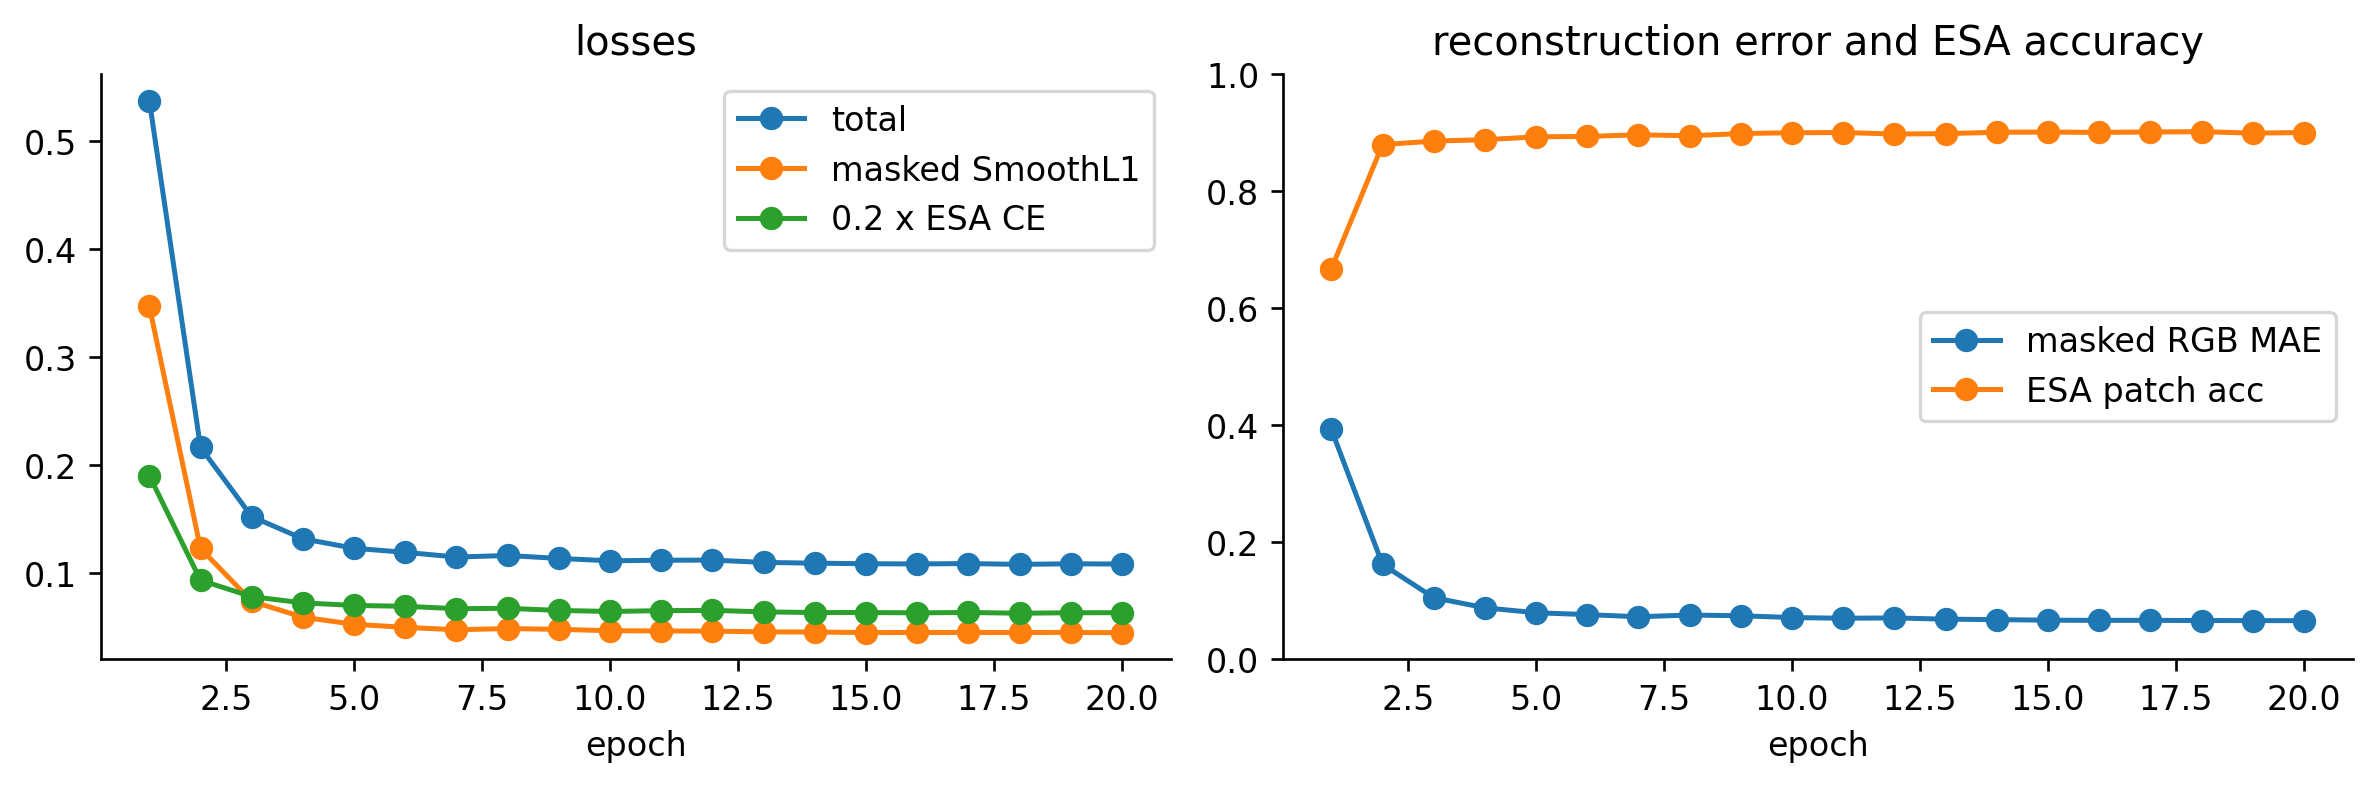

In [40]:
epochs = [h["epoch"] for h in history]
fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
axes[0].plot(epochs, [h["loss"] for h in history], marker="o", label="total")
axes[0].plot(epochs, [h["rec"] for h in history], marker="o", label="masked SmoothL1")
axes[0].plot(epochs, [PATCH_LOSS_WEIGHT * h["esa"] for h in history], marker="o", label="0.2 x ESA CE")
axes[0].set_title("losses")
axes[0].set_xlabel("epoch")
axes[0].legend()

axes[1].plot(epochs, [h["rec_mae"] for h in history], marker="o", label="masked RGB MAE")
axes[1].plot(epochs, [h["esa_acc"] for h in history], marker="o", label="ESA patch acc")
axes[1].set_title("reconstruction error and ESA accuracy")
axes[1].set_xlabel("epoch")
axes[1].set_ylim(0, 1)
axes[1].legend()
plt.tight_layout()

## Reconstruction examples

The model now does pixel-space RGB regression, so we can compare the target chip, the masked input it actually saw, and the predicted RGB image side by side. The fourth panel shows the per-pixel absolute error inside the masked tokens.

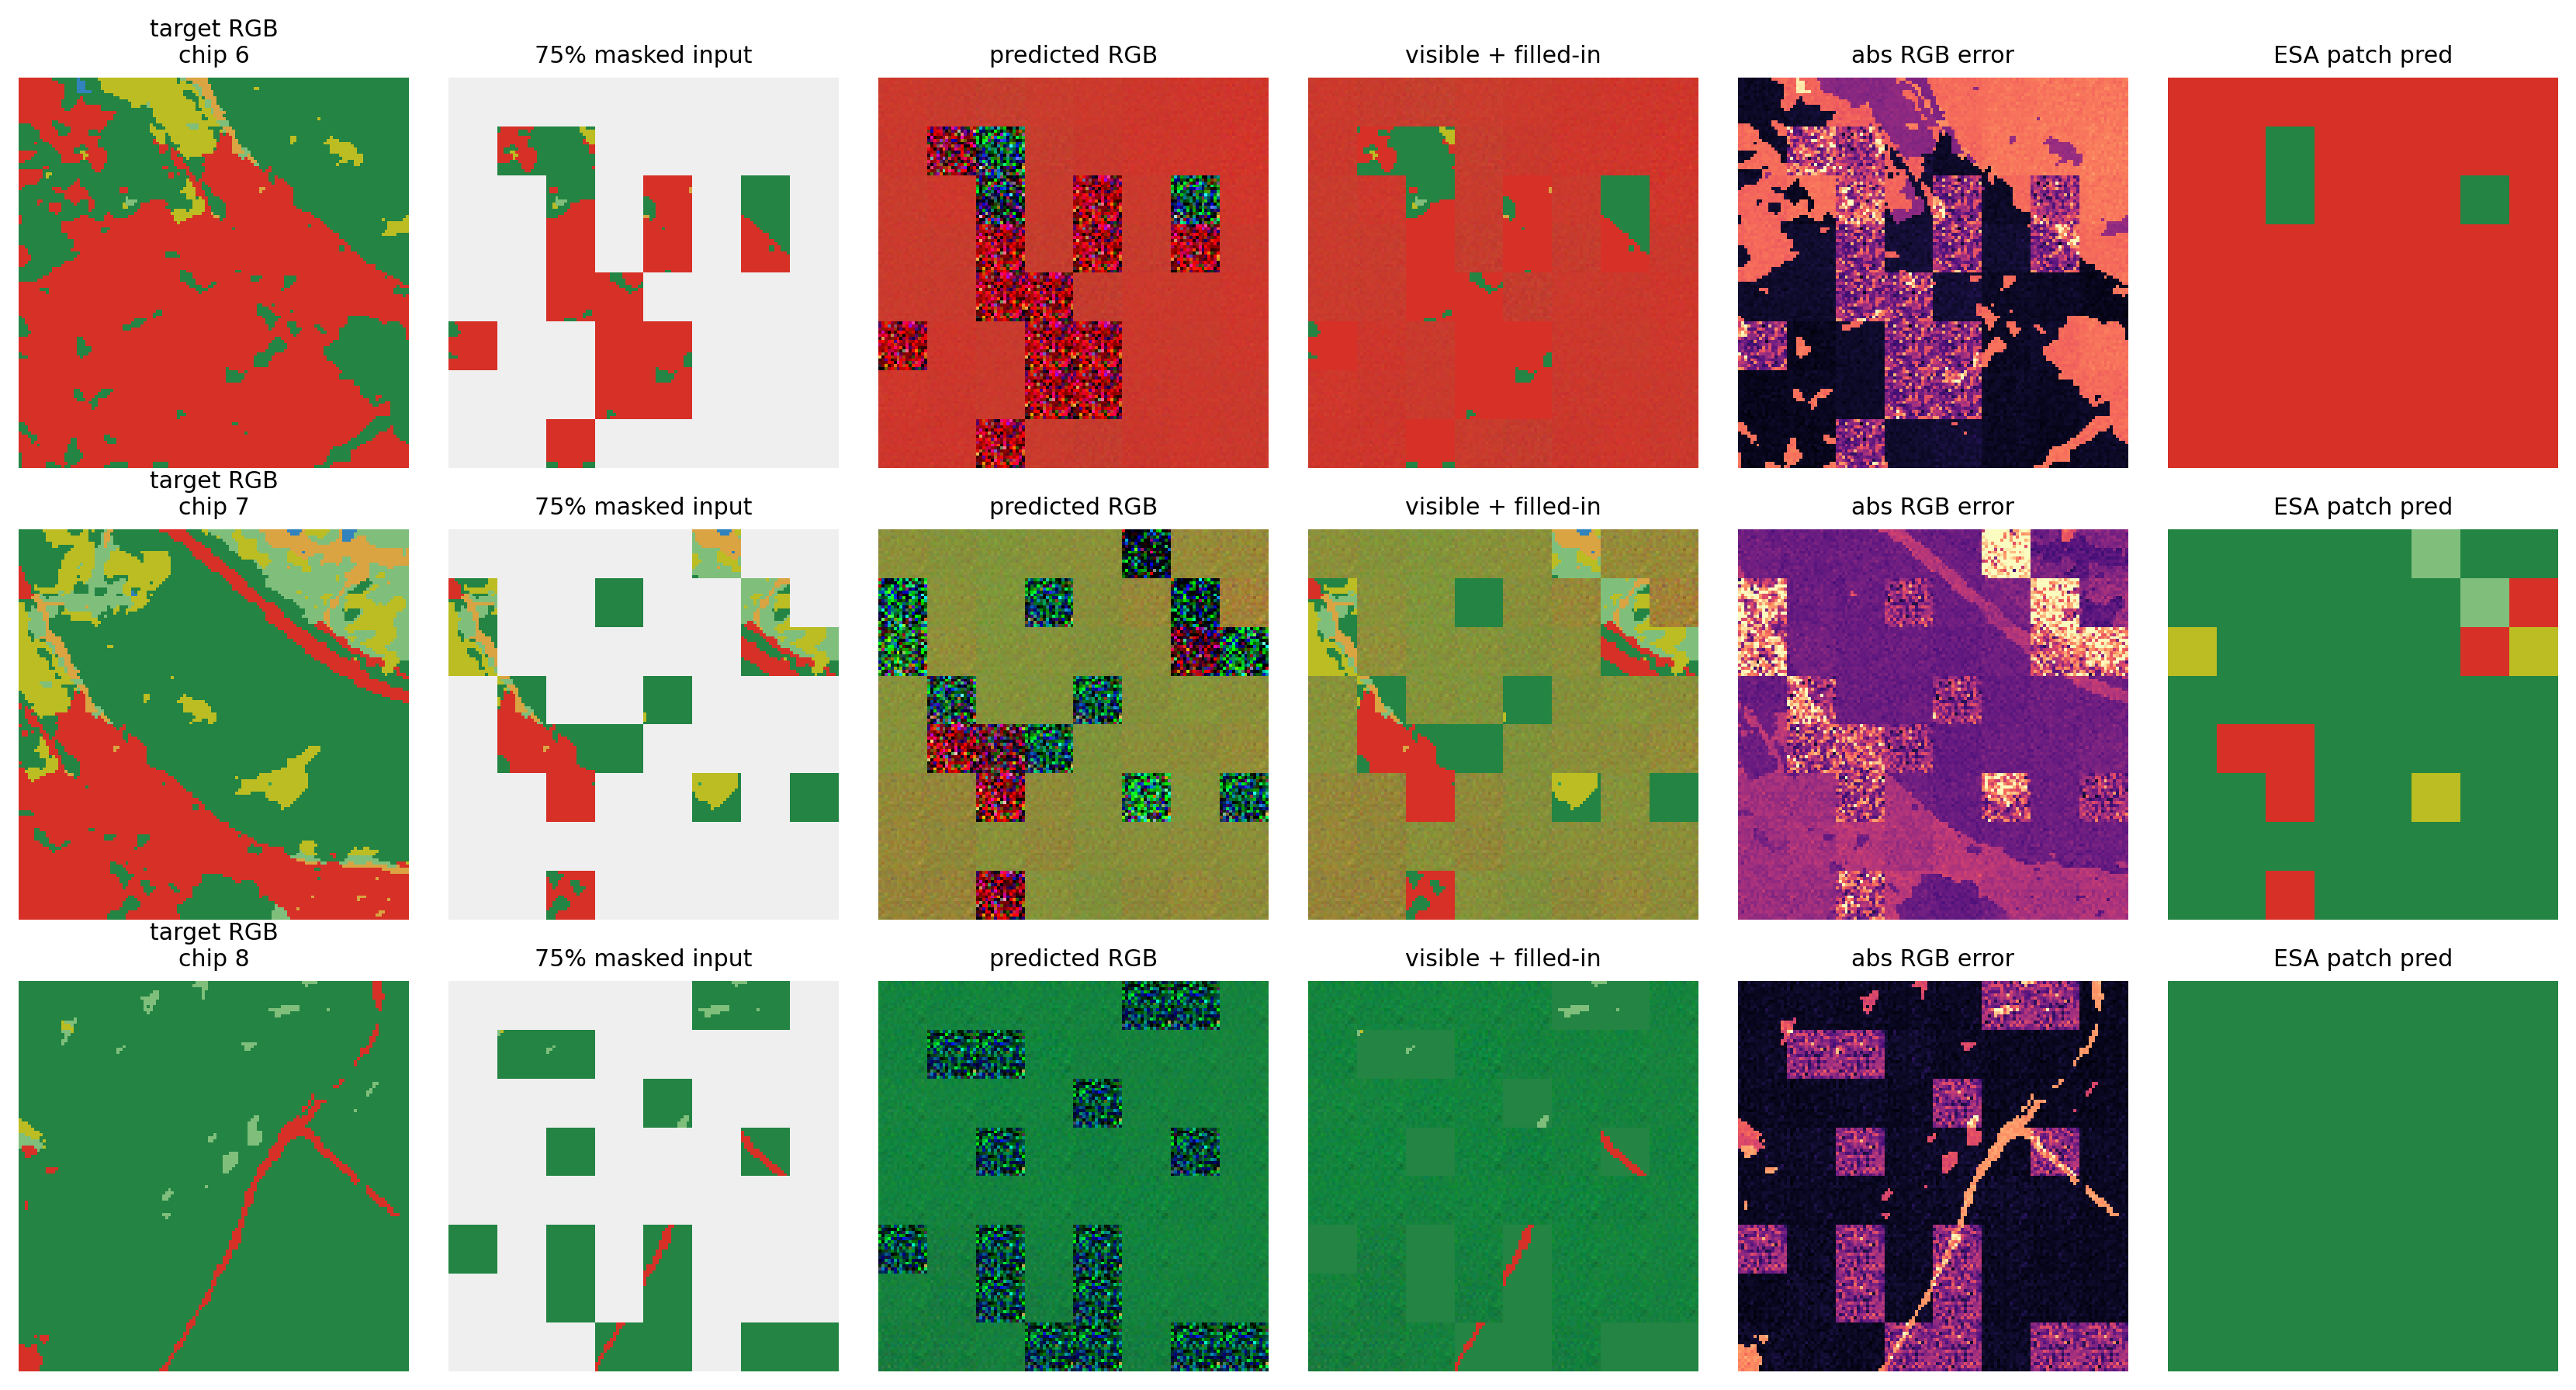

In [41]:
def masked_rgb_input(x_chip, mask):
    """3 x H x W RGB chip + 64-token mask -> H x W x 3 image with masked patches greyed out."""
    img = x_chip.detach().cpu().numpy().transpose(1, 2, 0).copy()
    patch_mask = mask.reshape(GRID_SIZE, GRID_SIZE).detach().cpu().numpy()
    pixel_mask = np.repeat(np.repeat(patch_mask, PATCH_SIZE, axis=0), PATCH_SIZE, axis=1).astype(bool)
    img[pixel_mask] = np.array([0.94, 0.94, 0.94])
    return img


def composite_visible_with_pred(x_chip, x_pred, mask):
    """Show ground truth on visible patches, prediction on masked patches."""
    img = x_chip.detach().cpu().numpy().transpose(1, 2, 0).copy()
    pred_img = x_pred.detach().cpu().numpy().transpose(1, 2, 0)
    patch_mask = mask.reshape(GRID_SIZE, GRID_SIZE).detach().cpu().numpy()
    pixel_mask = np.repeat(np.repeat(patch_mask, PATCH_SIZE, axis=0), PATCH_SIZE, axis=1).astype(bool)
    img[pixel_mask] = pred_img[pixel_mask]
    return img


def run_examples(indices):
    xs, _labels, patch_labels = zip(*(dataset[i] for i in indices))
    x = torch.stack(xs).to(device)
    patch_labels = torch.stack(patch_labels).reshape(len(indices), -1).to(device)
    generator = torch.Generator(device=device).manual_seed(7)
    mask = random_patch_mask(len(indices), generator=generator)
    with torch.no_grad():
        pixel_preds_tokens, patch_logits = model(x, mask)
    return (
        x.cpu(),
        patch_labels.cpu(),
        mask.cpu(),
        preds_tokens_to_image(pixel_preds_tokens).cpu(),
        patch_logits.cpu(),
    )


example_ids = [6, 7, 8]
xs, patch_targets, masks, preds, patch_logits = run_examples(example_ids)
patch_preds = patch_logits.argmax(dim=-1).reshape(len(example_ids), GRID_SIZE, GRID_SIZE)

fig, axes = plt.subplots(len(example_ids), 6, figsize=(14, 7.5))
for row, idx in enumerate(example_ids):
    target_rgb = rgb_chip_to_image(xs[row])
    pred_rgb = rgb_chip_to_image(preds[row])
    composite = composite_visible_with_pred(xs[row], preds[row], masks[row])
    error = np.abs(target_rgb - pred_rgb).mean(axis=2)
    panels = [
        (target_rgb, f"target RGB\nchip {idx}"),
        (masked_rgb_input(xs[row], masks[row]), "75% masked input"),
        (pred_rgb, "predicted RGB"),
        (composite, "visible + filled-in"),
        (error, "abs RGB error"),
        (labels_to_rgb(patch_preds[row]), "ESA patch pred"),
    ]
    for col, (image, title) in enumerate(panels):
        ax = axes[row, col]
        if col == 4:
            im = ax.imshow(image, cmap="magma", vmin=0, vmax=0.5, interpolation="nearest")
        else:
            ax.imshow(image, interpolation="nearest")
        ax.set_title(title, fontsize=9)
        ax.axis("off")
plt.tight_layout()

## ESA patch classification diagnostic

The auxiliary head is not just a side plot. It is the weak supervision signal that teaches each token a semantic land-cover summary. Below we evaluate patch predictions across the sampled chips using a fixed mask pattern.

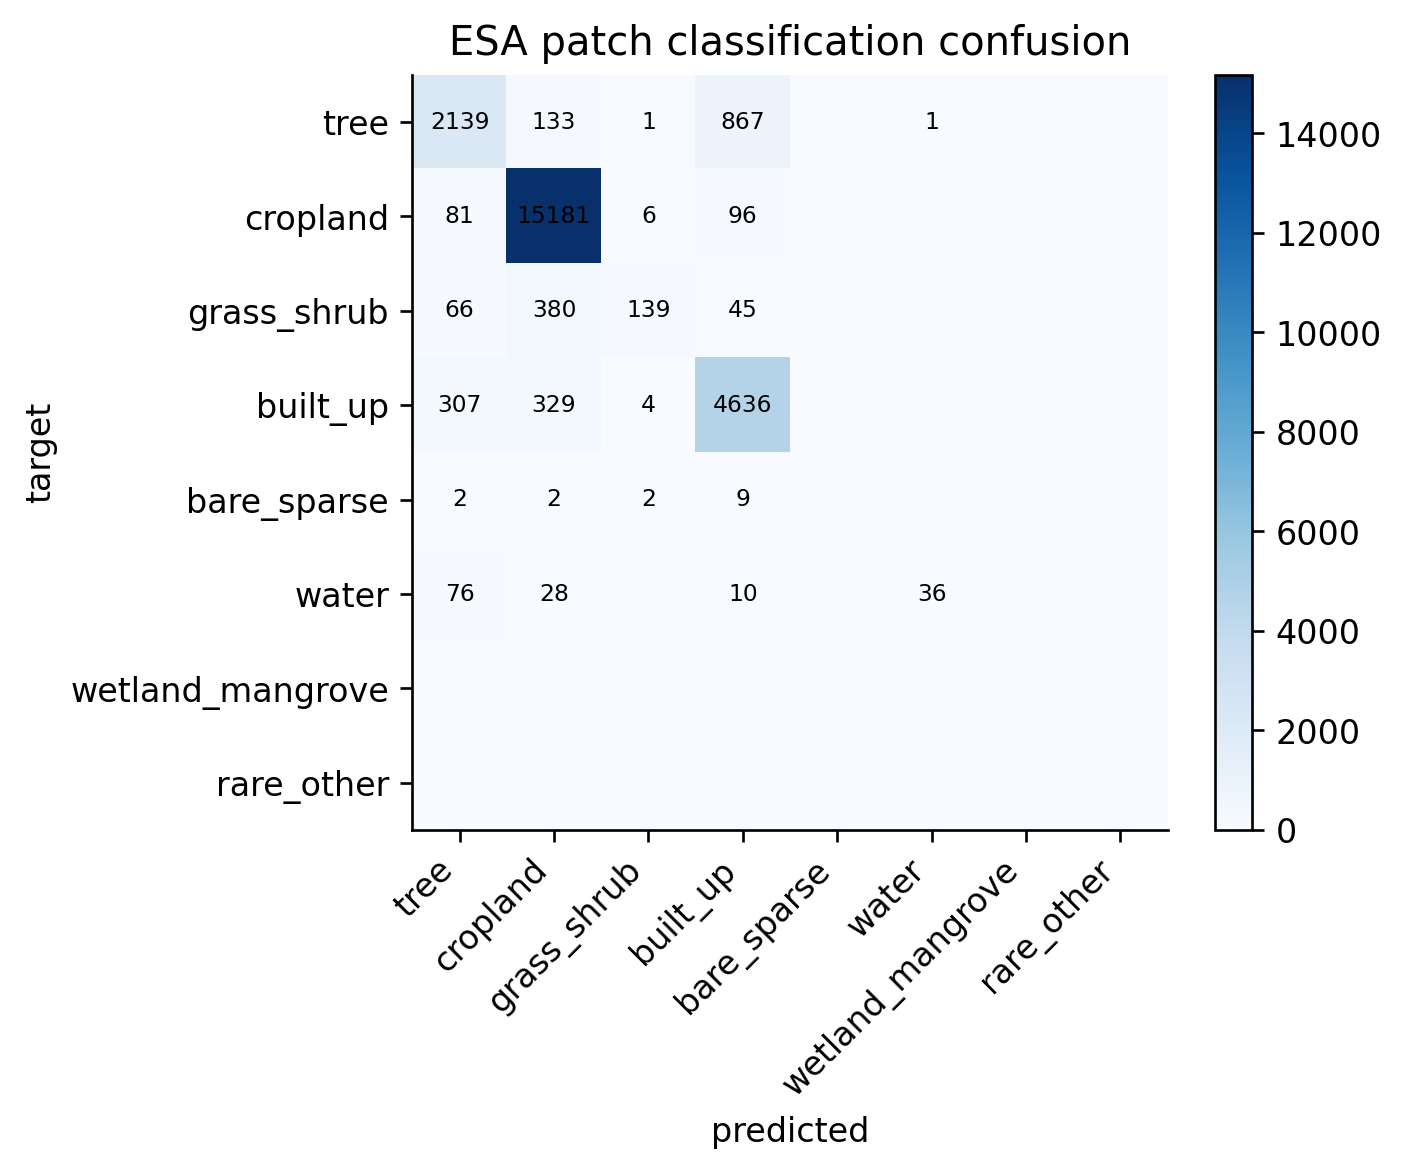

In [42]:
confusion = torch.zeros(NUM_CLASSES, NUM_CLASSES, dtype=torch.int64)
model.eval()
with torch.no_grad():
    for x, _labels, patch_labels in DataLoader(dataset, batch_size=BATCH_SIZE):
        x = x.to(device)
        patch_labels = patch_labels.reshape(x.size(0), -1).to(device)
        mask = random_patch_mask(x.size(0))
        _pixel_preds_tokens, patch_logits = model(x, mask)
        pred = patch_logits.argmax(dim=-1)
        for target_id, pred_id in zip(patch_labels.reshape(-1).cpu(), pred.reshape(-1).cpu()):
            confusion[target_id, pred_id] += 1

confusion_np = confusion.numpy()
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(confusion_np, cmap="Blues")
ax.set_title("ESA patch classification confusion")
ax.set_xticks(range(NUM_CLASSES), CLASS_NAMES, rotation=45, ha="right")
ax.set_yticks(range(NUM_CLASSES), CLASS_NAMES)
ax.set_xlabel("predicted")
ax.set_ylabel("target")
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        if confusion_np[i, j] > 0:
            ax.text(j, i, str(confusion_np[i, j]), ha="center", va="center", fontsize=7)
plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()

## Token scale: toy run vs BharatEO-v0

The toy run is bigger now, but the accounting is the same as the serious run.

For this notebook (`DATASET_SIZE = 384`, `EPOCHS = 20`):

- tokens per chip: `64`
- total patch-token presentations: `~492K`
- visible patch-token inputs at 75% masking: `~123K`
- masked patch-token reconstruction targets: `~369K`
- masked RGB pixel regression targets: `~94M`

For a BharatEO-v0 pretraining run with `1M` chips and `100` epochs:

- total patch-token presentations: `6.4B`
- visible patch-token inputs at 75% masking: `1.6B`
- masked patch-token reconstruction targets: `4.8B`
- masked reflectance regression targets: `1.2T`

That is why the small notebook is useful: the tensor shapes and losses are the same kind of machinery, just scaled down by four orders of magnitude.

## What changes for Sentinel-2 BharatEO-v0?

Now that the input is already 3-channel pixel data and the reconstruction objective is already a smooth-L1 regression, the gap to a real Sentinel-2 MAE is small.

Keep:

- the `128 x 128` chip size and `16 x 16` patch size (`64` tokens),
- the masked SmoothL1 reconstruction objective,
- the ESA patch-label auxiliary objective,
- the multi-ROI sampling and geography splits.

Change:

- input from `3 x 128 x 128` palette RGB to `10 x 128 x 128` Sentinel-2 L2A reflectance (or `4 x 128 x 128` for an RGB+NIR start),
- normalize each band by its dataset-wide mean / std before the MAE,
- visual reconstruction panels show Sentinel-2 `B4-B3-B2` true color and `B8-B4-B3` false color,
- dataset construction loops over Sentinel-2 + WorldCover pairs sampled across many tiles, not three crops in one tile.

The pedagogical point survives: **WorldCover supplies the weak semantic objective; the optical sensor supplies the image signal for the real foundation encoder.**